In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [122]:
# ==========================================
# STEP 1 : LOAD DATASET
# ==========================================

df = pd.read_csv("student_pca_dataset.csv")

print("Dataset Preview:\n")
print(df.head())

print("\nDataset Shape:", df.shape)


Dataset Preview:

   study_hours  attendance  previous_score  assignment_score  internal_marks
0           11          74              66                71              67
1            4          55              42                47              40
2           11          81              68                71              70
3            1          50              35                32              31
4            9          76              58                60              57

Dataset Shape: (100, 5)


In [123]:
# ==========================================
# STEP 2 : SELECT FEATURES
# ==========================================

X = df[['study_hours',
        'attendance',
        'previous_score',
        'assignment_score',
        'internal_marks']]

print("\nOriginal Dataset")
print(X.head())


Original Dataset
   study_hours  attendance  previous_score  assignment_score  internal_marks
0           11          74              66                71              67
1            4          55              42                47              40
2           11          81              68                71              70
3            1          50              35                32              31
4            9          76              58                60              57


In [124]:
# ==========================================
# STEP 3 : CALCULATE MEAN
# ==========================================

mean = np.mean(X, axis=0)

print("\nMean of each feature:\n")
print(mean)


Mean of each feature:

study_hours          8.77
attendance          71.15
previous_score      65.01
assignment_score    64.17
internal_marks      64.22
dtype: float64


In [125]:
# ==========================================
# STEP 4 : STANDARDIZE DATA
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized Data\n")
print(X_scaled[:5])



Standardized Data

[[ 0.4935235   0.22003458  0.05587873  0.37947894  0.15626078]
 [-1.0556534  -1.24686263 -1.29875714 -0.9539756  -1.36137987]
 [ 0.4935235   0.7604704   0.16876505  0.37947894  0.32488752]
 [-1.71958636 -1.63288822 -1.69385927 -1.78738469 -1.86726008]
 [ 0.05090153  0.37444482 -0.39566656 -0.23168773 -0.40582835]]


In [126]:
# ==========================================
# STEP 5 : COVARIANCE MATRIX
# ==========================================

covariance_matrix = np.cov(X_scaled.T)

print("\nCovariance Matrix\n")
print(covariance_matrix)


Covariance Matrix

[[1.01010101 0.9831463  0.97247272 0.96169855 0.96250974]
 [0.9831463  1.01010101 0.95741109 0.94454662 0.94532171]
 [0.97247272 0.95741109 1.01010101 0.98977202 0.98878933]
 [0.96169855 0.94454662 0.98977202 1.01010101 0.99059896]
 [0.96250974 0.94532171 0.98878933 0.99059896 1.01010101]]


In [127]:
# ==========================================
# STEP 6 : EIGEN VALUES & EIGEN VECTORS
# ==========================================

eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

print("\nEigen Values\n")
print(eigen_values)

print("\nEigen Vectors\n")
print(eigen_vectors)


Eigen Values

[4.88874692 0.09792078 0.02468223 0.01887557 0.02027956]

Eigen Vectors

[[ 0.44730282 -0.41077997 -0.77710825  0.12090516  0.11253759]
 [ 0.44274444 -0.6605159   0.60627279  0.00527514  0.01007896]
 [ 0.44997362  0.24123828 -0.05015599 -0.57058682 -0.64128222]
 [ 0.44798033  0.4171975   0.12428746  0.75265919 -0.20812652]
 [ 0.44803451  0.4033967   0.10282544 -0.30543238  0.72984531]]


In [128]:
# ==========================================
# STEP 7 : APPLY PCA
# ==========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nReduced Dataset Shape")
print(X_pca.shape)

print("\nPrincipal Components")
print(X_pca[:10])

print("\nExplained Variance Ratio")
print(pca.explained_variance_ratio_)


Reduced Dataset Shape
(100, 2)

Principal Components
[[ 5.83326811e-01  1.13233074e-01]
 [-2.64595215e+00  3.26845630e-03]
 [ 9.48948227e-01  3.74943551e-01]
 [-3.89163011e+00  1.22642416e-01]
 [-2.75104409e-01  6.24055361e-01]
 [ 2.15121739e+00  1.31998554e-02]
 [ 1.82154211e-01  2.59699646e-01]
 [ 1.71223020e+00  5.51487021e-02]
 [-2.90195999e+00  3.96526816e-01]
 [-3.05555132e+00 -3.22051614e-01]]

Explained Variance Ratio
[0.96797189 0.01938831]


In [129]:
# ==========================================
# STEP 8 : CREATE NEW DATAFRAME
# ==========================================

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

print("\nPCA Dataset\n")
print(pca_df.head())


PCA Dataset

        PC1       PC2
0  0.583327  0.113233
1 -2.645952  0.003268
2  0.948948  0.374944
3 -3.891630  0.122642
4 -0.275104  0.624055


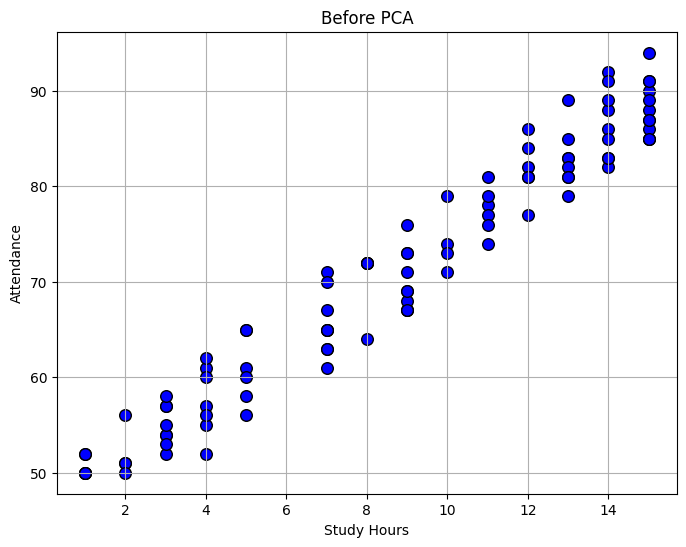

In [130]:
# Before PCA
plt.figure(figsize=(8,6))

plt.scatter(
    df["study_hours"],
    df["attendance"],
    color="blue",
    edgecolors="black",
    s=70
)

plt.title("Before PCA")
plt.xlabel("Study Hours")
plt.ylabel("Attendance")

plt.grid(True)

plt.show()

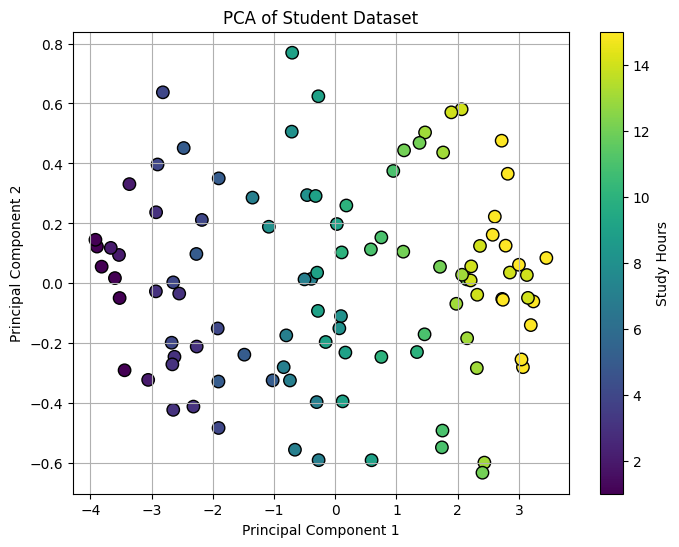

In [131]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["study_hours"],
    cmap="viridis",
    s=80,
    edgecolor="black"
)

plt.colorbar(label="Study Hours")

plt.title("PCA of Student Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (5,) and arg 1 with shape (2,).

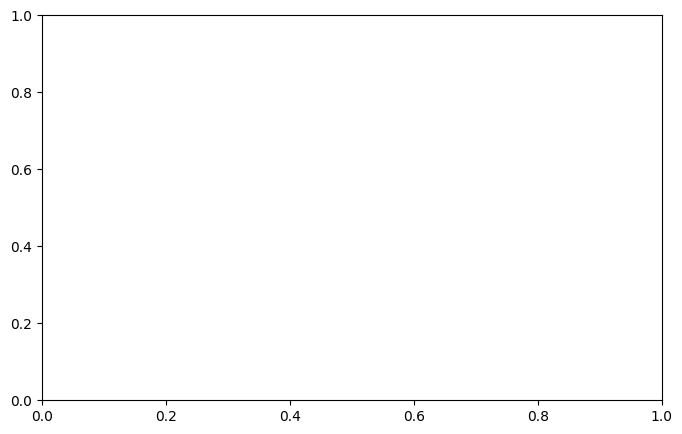

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    color="green"
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Explained Variance Ratio")

plt.grid(True)

plt.show()